# preprocessing

In [1]:
# from google.colab import files
# uploaded = files.upload()

In [ ]:
import pandas as pd

raw_data = pd.read_csv("data/raw/ecommerce_customer_churn_dataset.csv", encoding='UTF-8', sep=',')

In [3]:
raw_data.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


### Описание признаков датасета

| Признак | Описание |
|--------|----------|
| **Age** | Возраст пользователя |
| **Gender** | Пол  |
| **Country** | Страна |
| **City** | Город |
| **Membership_Years** | Стаж клиента |
| **Login_Frequency** | Частота входов на сайт |
| **Session_Duration_Avg** | Средняя длительность сессии на сайте |
| **Pages_Per_Session** | Число страниц, просмотренных за сессию |
| **Cart_Abandonment_Rate** | Доля брошенных корзин |
| **Wishlist_Items** | Число товаров в избранном |
| **Email_Open_Rate** | Доля открытия почты |
| **Mobile_App_Usage** | Использование мобильного приложения |
| **Social_Media_Engagement_Score** | Уровень вовлечения через соцсети |
| **Total_Purchases** | Число покупок |
| **Average_Order_Value** | Средний чек при покупке |
| **Days_Since_Last_Purchase** | Давность последней покупки |
| **Discount_Usage_Rate** | Доля заказов со скидкой |
| **Return_Rate** | Доля возвратов |
| **Payment_Method_Diversity** | Число способов оплаты |
| **Customer_Service_Calls** | Звонки в поддержку |
| **Product_Reviews_Written** | Число написанных отзывов |
| **Lifetime_Value** | Выручка |
| **Credit_Balance** | Баланс клиента |
| **Signup_Quarter** | Квартал регистрации |
| **Churned** | Ушел ли клиент? |





### Обработка датасета

In [4]:
raw_data.duplicated().sum()

np.int64(0)

In [5]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

#### Обработка пропусков

In [6]:

def show_nan_info(data):
  nan_data = data.isna().sum()
  nan_data = nan_data[nan_data > 0].to_frame(name="nan_count")

  nan_data['nan_%'] = (nan_data["nan_count"] / data.shape[0]) * 100
  return nan_data.sort_values(by='nan_%', ascending=False)

nan_data = show_nan_info(raw_data)
nan_data

,nan_count,nan_%
Social_Media_Engagement_Score,6000,12.000
Credit_Balance,5500,11.000
Mobile_App_Usage,5000,10.000
Returns_Rate,4491,8.982
Wishlist_Items,4000,8.000
Discount_Usage_Rate,3500,7.000
Product_Reviews_Written,3500,7.000
Session_Duration_Avg,3399,6.798
Pages_Per_Session,3000,6.000
Days_Since_Last_Purchase,3000,6.000


Посмотрим на то каких типов эти признаки

In [7]:
nan_cols_list = list(nan_data.index)
raw_data[nan_cols_list].dtypes

,0
Social_Media_Engagement_Score,float64
Credit_Balance,float64
Mobile_App_Usage,float64
Returns_Rate,float64
Wishlist_Items,float64
Discount_Usage_Rate,float64
Product_Reviews_Written,float64
Session_Duration_Avg,float64
Pages_Per_Session,float64
Days_Since_Last_Purchase,float64


In [8]:
data = raw_data

Проанализируем каждый из признаков с пропусками:
 - Построим распределение числовых значений
 - Проверим возможность заполнения нулем или медианой

##### Social_Media_Engagement_Score

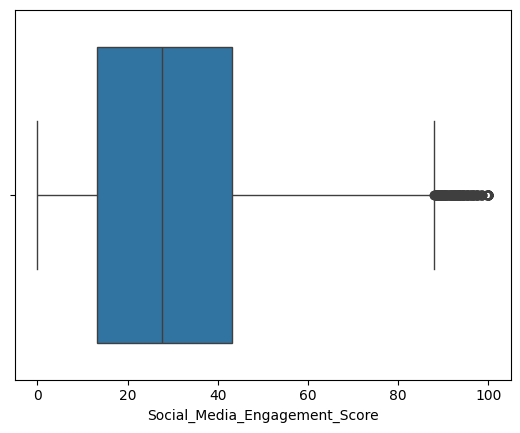

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x='Social_Media_Engagement_Score', data=raw_data)
plt.show()

Признак показывает уровень вовлечения через соцсети, заполним пропуски медианой сгруппированной по полу.

In [10]:
data['Social_Media_Engagement_Score'] = data.groupby('Gender')['Social_Media_Engagement_Score'].transform(lambda x: x.fillna(x.median()))

##### Credit_Balance

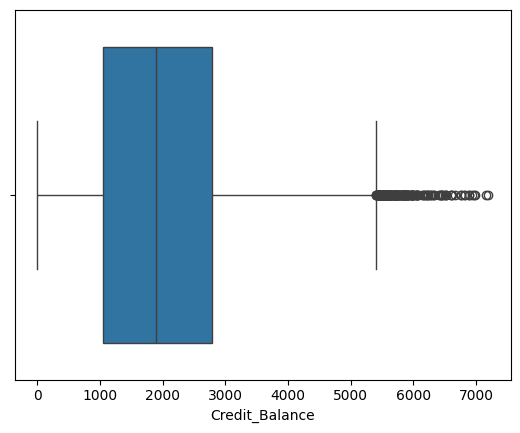

In [11]:
sns.boxplot(x='Credit_Balance', data=raw_data)
plt.show()

Этот признак имеет большие значения, лучше заполнить пропуски медианой сгруппированной по полу

In [12]:
data['Credit_Balance'] = data.groupby('Gender')['Credit_Balance'].transform(lambda x: x.fillna(x.median()))

##### Mobile_App_Usage

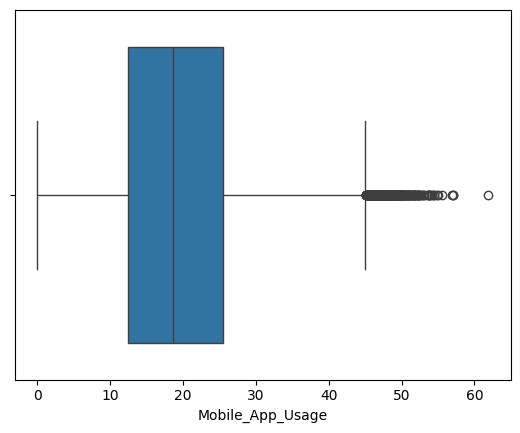

In [13]:
sns.boxplot(x='Mobile_App_Usage', data=raw_data)
plt.show()

Признак показывает использование мобильного приложения, логично заполнить пропуски нулем

In [14]:
data['Mobile_App_Usage'] = data['Mobile_App_Usage'].fillna(0)

##### Returns_Rate

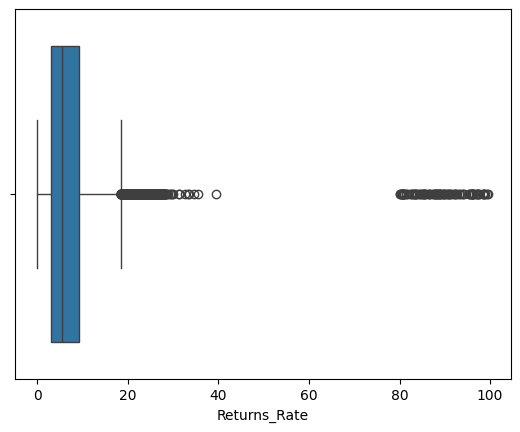

In [15]:
sns.boxplot(x='Returns_Rate', data=raw_data)
plt.show()

Признак показывает количество возвратов, логично заполнить пропуски нулем

In [16]:
data['Returns_Rate'] = data['Returns_Rate'].fillna(0)

##### Wishlist_Items

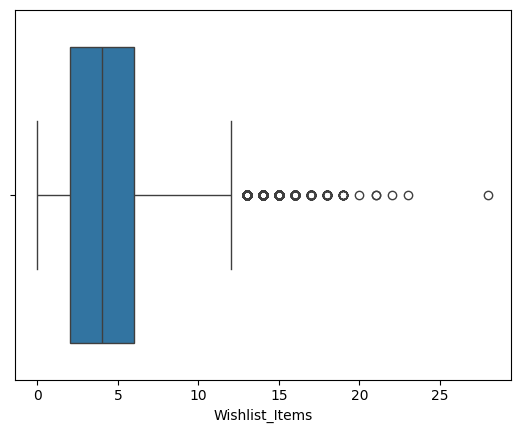

In [17]:
sns.boxplot(x='Wishlist_Items', data=raw_data)
plt.show()

Признак показывает количество товаров в избранном, логично заполнить пропуски нулем, так как в избранном может не быть ни одного товара

In [18]:
data['Wishlist_Items'] = data['Wishlist_Items'].fillna(0)

##### Discount_Usage_Rate

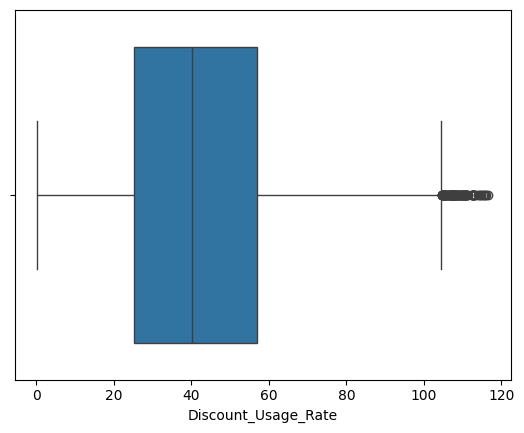

In [19]:
sns.boxplot(x='Discount_Usage_Rate', data=raw_data)
plt.show()

Признак показывает количество скидок, логично заполнить пропуски нулем, так как можно не пользоваться скидками, либо не иметь покупок

In [20]:
data['Discount_Usage_Rate'] = data['Discount_Usage_Rate'].fillna(0)

##### Product_Reviews_Written

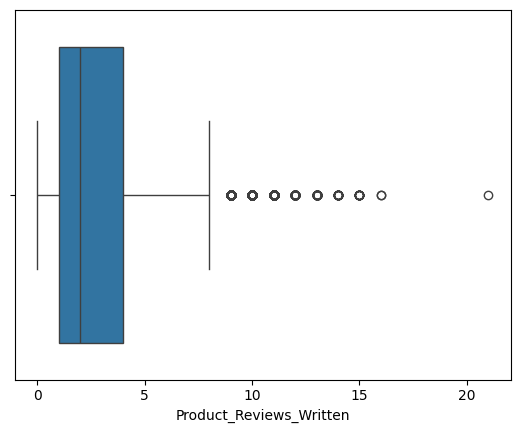

In [21]:
sns.boxplot(x='Product_Reviews_Written', data=raw_data)
plt.show()

Признак показывает количество написанных отзывов, логично заполнить пропуски нулем

In [22]:
data['Product_Reviews_Written'] = data['Product_Reviews_Written'].fillna(0)

##### Session_Duration_Avg

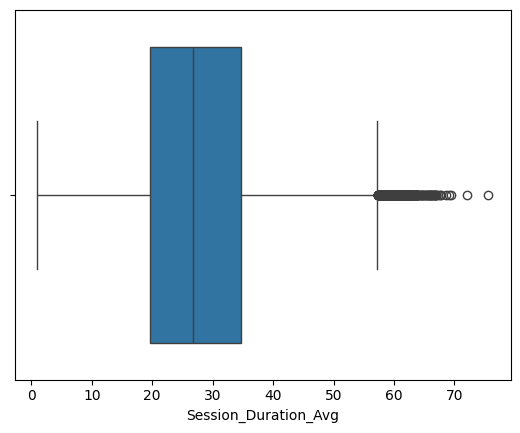

In [23]:
sns.boxplot(x='Session_Duration_Avg', data=raw_data)
plt.show()

Признак показывает среднюю длительность на сайте, заполним пустые значения медианой по полу

In [24]:
data['Session_Duration_Avg'] = data.groupby('Gender')['Session_Duration_Avg'].transform(lambda x: x.fillna(x.median()))

##### Pages_Per_Session

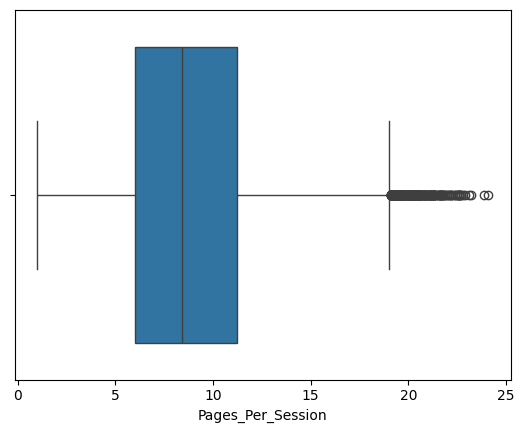

In [25]:
sns.boxplot(x='Pages_Per_Session', data=raw_data)
plt.show()

Признак показывает количество просмотренных страниц, заполним пропуски средним значением по полу

In [26]:
data['Pages_Per_Session'] = data.groupby('Gender')['Pages_Per_Session'].transform(lambda x: x.fillna(x.median()))

##### Days_Since_Last_Purchase

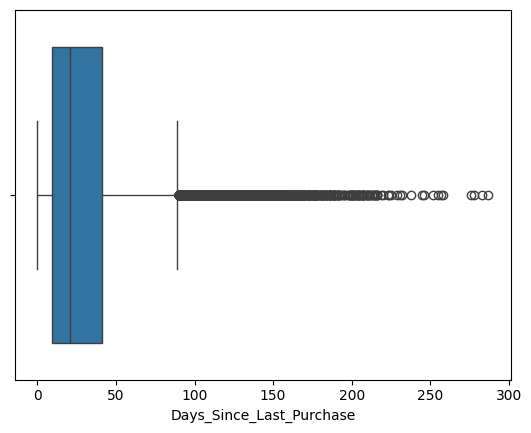

In [27]:
sns.boxplot(x='Days_Since_Last_Purchase', data=raw_data)
plt.show()

Признак показывает количество дней с прошлого заказа, логично заполнить пропуски нулем, так как это может быть первый заказ

In [28]:
data['Days_Since_Last_Purchase'] = data['Days_Since_Last_Purchase'].fillna(0)

##### Email_Open_Rate

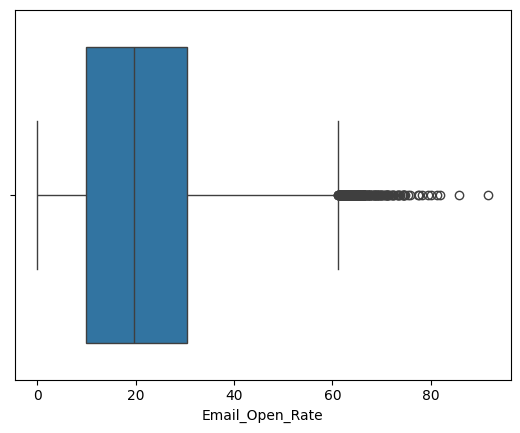

In [29]:
sns.boxplot(x='Email_Open_Rate', data=raw_data)
plt.show()

Признак показывает долю открытия почты, логично заполнить пропуски нулем

In [30]:
data['Email_Open_Rate'] = data['Email_Open_Rate'].fillna(0)

##### Payment_Method_Diversity

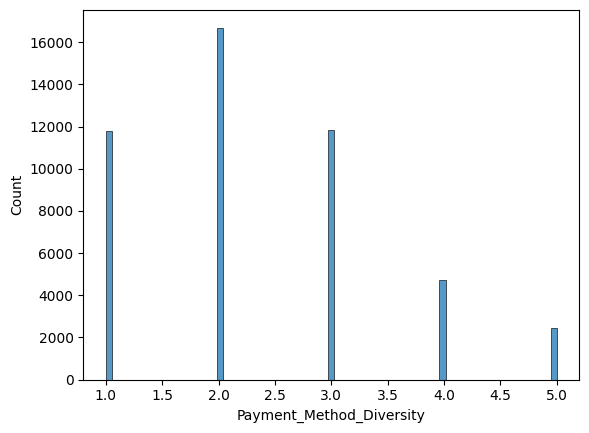

In [31]:
sns.histplot(x='Payment_Method_Diversity', data=raw_data)
plt.show()

Признак показывает способ оплаты, заполним его медианой

In [32]:
data['Payment_Method_Diversity'] = data['Payment_Method_Diversity'].fillna(data['Payment_Method_Diversity'].median())

##### Age

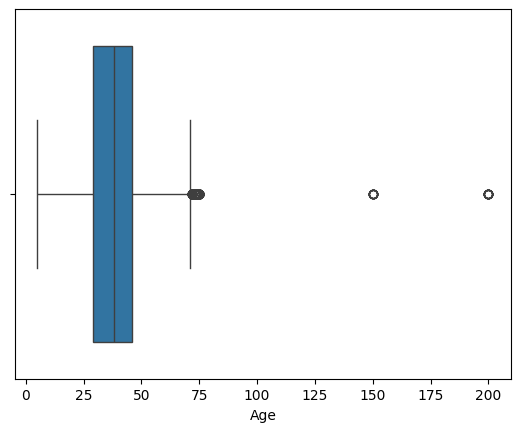

In [33]:
sns.boxplot(x='Age', data=raw_data)
plt.show()

Признак показывает способ оплаты, заполним его медианой сгруппированной по полу

In [34]:
data['Age'] = data.groupby('Gender')['Age'].transform(lambda x: x.fillna(x.median()))

##### Customer_Service_Calls

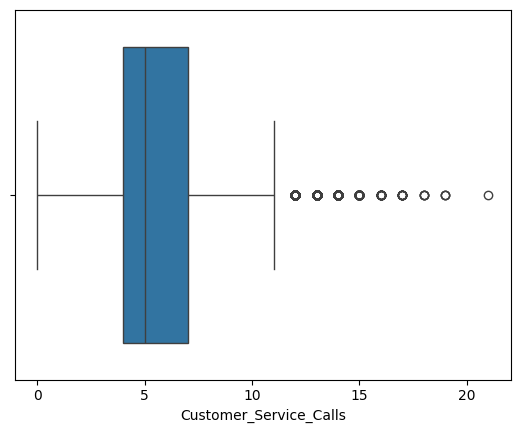

In [35]:
sns.boxplot(x='Customer_Service_Calls', data=raw_data)
plt.show()

Признак показывает количество звонков в поддержку, заполним признак нулем

In [36]:
data['Customer_Service_Calls'] = data['Customer_Service_Calls'].fillna(0)

In [ ]:
show_nan_info(data)

,nan_count,nan_%


#### Обработка выбросов

Для обработки выбросов проанализирую то, какие значения принимают признаки, построив диаграмму

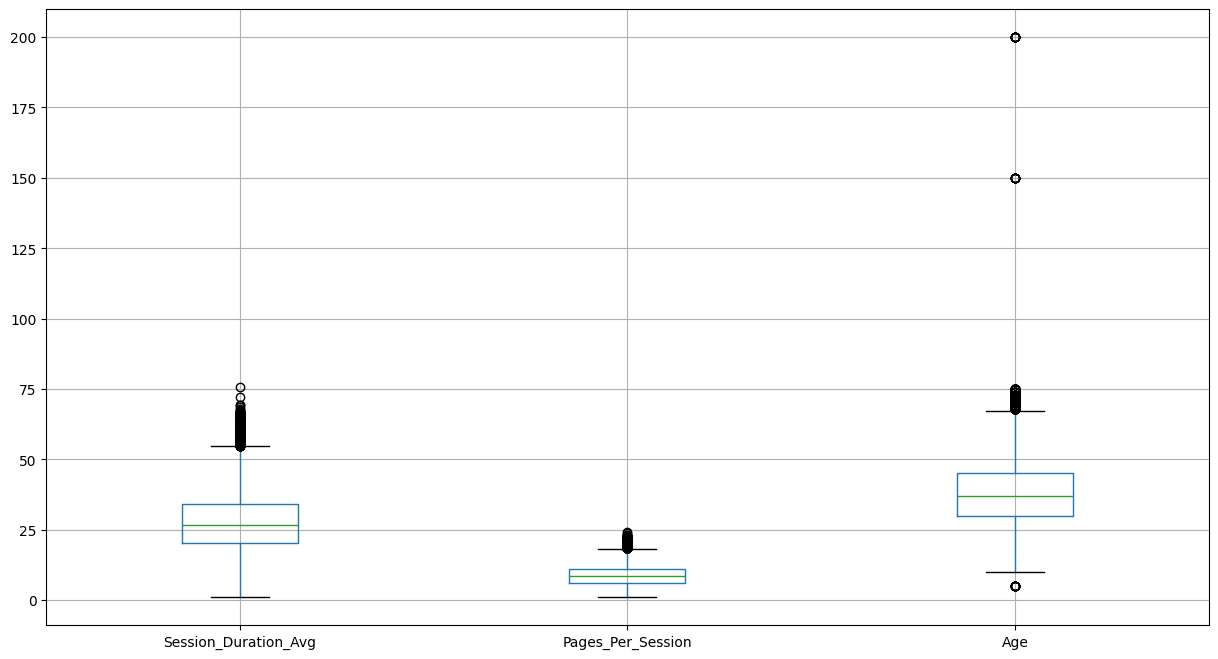

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# посмотрю на распределения всех числовых типов и опеределю, где необходимо удалять выбросы
# для наглядности распределения логарифмирую
def plot_log_boxplots(df):
    # num_df = df.select_dtypes(include=['number'])
    log_df = df.apply(lambda col: np.log(col + 1) if col.min() >= 0 else col)

    plt.figure(figsize=(15, 8))
    # log_df.boxplot()
    df.boxplot()
    plt.show()

plot_log_boxplots(raw_data[[
                     'Session_Duration_Avg',
                     'Pages_Per_Session',
                     'Age',
                     ]])

Видно "неадекватные" значения для age. Можно обрезать до стандартного (0,90)

In [43]:
raw_data['Age'] = raw_data['Age'].clip(0, 90)

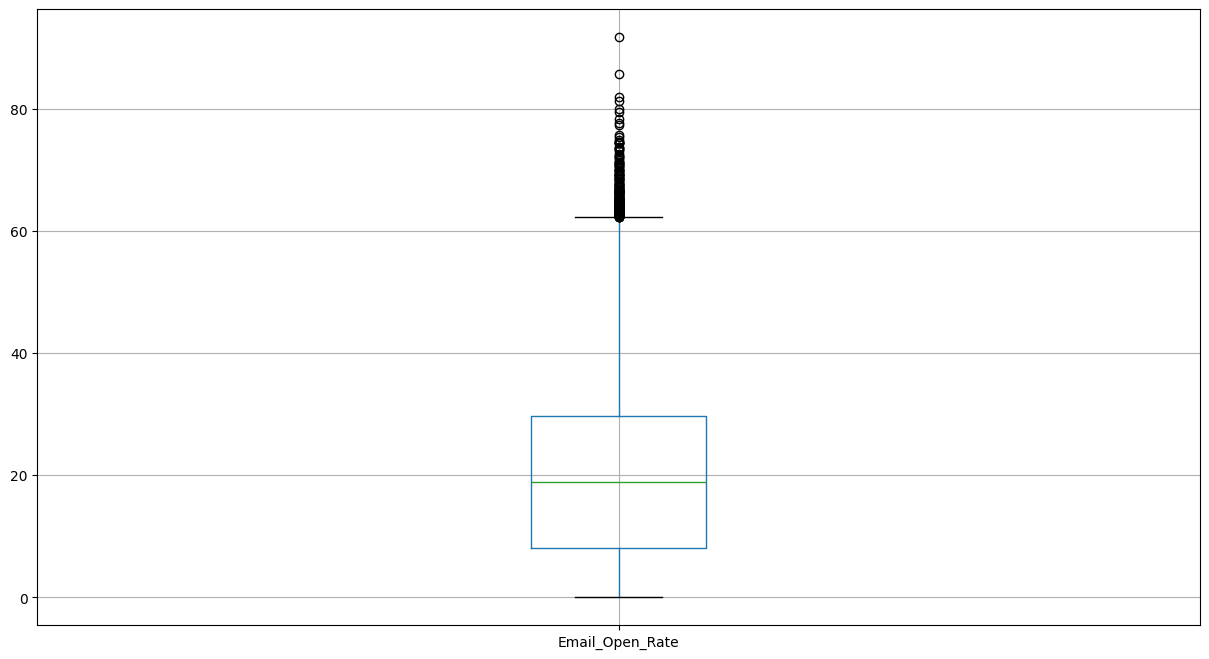

In [44]:
# диапазон (0, 100) для признаков _Rate
plot_log_boxplots(raw_data[
    ['Email_Open_Rate']
])

# todo
raw_data['Email_Open_Rate'] = raw_data['Email_Open_Rate'].clip(0, 90)

#### Поиск дупликатов

In [45]:
print("Число дубликатов до:", raw_data.duplicated().sum())
data = raw_data.drop_duplicates()
print("Число дубликатов после:", raw_data.duplicated().sum())

Число дубликатов до: 0
Число дубликатов после: 0


По данным видно что всё поведения пользователя сводится к следующим типам:

- Просмотр товара на странице (view)
- Добавление товара в корзину (addtocart)
- Покупка товара (transaction)

Тут можно наблюдать некую воронку: все кто дошел до transaction - купил товар на сайте, в дальнейшем сделаем из этого целевой признак.

На этом этапе логично предположить что пропуски в transactionid связаны с тем что покупка не была совершена.
Поэтому создадим булевый признак has_transaction, отвечающий на вопрос "Была ли совершена покупка?"
Пропуски же в признаке transaction_id убирать не стоить, т.к. это оставит выборку только покупок, и "закроет глаза" на случае когда пользователь покупку не совершил. Оставим эти пропуски как "осознанные" в контексте решаемой задачи.

In [46]:
raw_data.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,37.751800,2.984009,11.624660,27.599070,8.717542,57.079973,3.954520,13.111576,123.117330,28.005300,...,6.080833,19.879322,5.66274,2.653580,29.156242,17.434446,2.33618,1440.626292,1958.434800,0.289000
std,11.230378,2.059105,7.810657,10.497494,3.663996,16.282723,3.274206,7.017312,175.569714,29.647097,...,6.164110,14.625496,2.69171,2.361001,19.308463,10.659451,1.08465,907.249443,1155.952428,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000
50%,37.000000,2.500000,11.000000,26.800000,8.400000,58.100000,3.000000,12.000000,112.970000,19.000000,...,4.900000,18.800000,5.00000,2.000000,27.700000,17.200000,2.00000,1243.415000,1899.000000,0.000000
75%,45.000000,4.000000,17.000000,34.000000,11.000000,68.700000,6.000000,17.000000,144.440000,39.000000,...,8.600000,29.700000,7.00000,4.000000,40.700000,24.600000,3.00000,1874.000000,2664.000000,1.000000
90%,53.000000,5.800000,22.000000,41.900000,13.700000,77.200000,8.000000,22.000000,179.000000,67.000000,...,12.800000,39.900000,9.00000,6.000000,55.800000,31.500000,4.00000,2637.133000,3520.000000,1.000000
95%,57.000000,7.100000,26.000000,46.700000,15.300000,81.900000,10.000000,24.700000,201.821000,87.000000,...,15.700000,46.100000,10.00000,7.000000,64.700000,35.600000,4.00000,3192.503500,4019.000000,1.000000
99%,65.000000,10.000000,32.000000,55.000000,18.200000,90.800000,14.000000,31.200000,252.300100,136.000000,...,21.600000,57.000000,13.00000,10.000000,81.700000,42.900000,5.00000,4420.197400,5004.010000,1.000000
max,90.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,90.000000,21.00000,21.000000,100.000000,61.900000,5.00000,8987.240000,7197.000000,1.000000


Просто угадать перцентиль нельзя, это может отрезать важную информацию в выборке, поэтому найдем оптимальный перцентиль при условии, что мы готовы "выбросить" не более 10% событий на сайте

In [47]:
# def compare_percentiles(data_by_visitors, range_percentiles, threshold_data_percent=1):
#   info = {}
#   for per in range_percentiles:
#     treshold = data_by_visitors.quantile(per)
#     removed_visitors = (data_by_visitors > treshold).sum()
#     removed_persent = (removed_visitors/ (data_by_visitors).count()) * 100
#     info.update([(round(per, 2), round(removed_persent, 2))])
#     print(f"Перцентиль:{round(per, 2)}, Процент удаленных пользователей: {round(removed_persent, 2)}")
#   return info

In [48]:
# _ = compare_percentiles(data_by_visitors=raw_data, range_percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

Общая картина понятна, сделаю прогон автомтически для подбора идеального перцентиля

In [49]:
# import numpy as np
# per_list = np.arange(0.5, 0.9, 0.01)
# res_dict = compare_percentiles(data_by_visitors=data_by_visitors, range_percentiles=per_list)

In [50]:
# threshold_data_percent = 10

# def get_best_percentile(dict_, treshold):
#   res = []
#   for k, v in dict_.items():
#     if v < threshold_data_percent:
#       res.append(k)
#   return res[0]

# best_perc = get_best_percentile(res_dict, threshold_data_percent)
# best_perc


Получили лучший перецентль для удаления выбросов

In [51]:
# data_by_visitors.describe(percentiles=[best_perc])

In [52]:
df = raw_data

### Создание новых признаков

In [53]:
df.head(15)

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,27.5,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,27.7,8.8,2.0,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.4,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4
5,35.0,Male,Japan,Tokyo,3.5,6.0,21.9,6.9,74.4,0.0,...,16.0,8.0,2.0,14.3,11.2,2.0,1995.43,2418.0,1,Q1
6,56.0,Male,Germany,Berlin,1.9,24.0,46.4,13.9,36.2,5.0,...,35.5,4.0,6.0,68.8,42.9,5.0,3003.57,2657.0,0,Q1
7,47.0,Female,USA,Houston,1.6,14.0,24.1,8.3,59.9,2.0,...,5.5,5.0,0.0,30.1,7.6,2.0,1394.04,2274.0,0,Q4
8,32.0,Male,Canada,Calgary,1.3,14.0,26.8,7.4,66.5,4.0,...,19.0,2.0,0.0,0.0,18.7,2.0,537.21,534.0,0,Q1
9,44.0,Male,USA,New York,3.6,13.0,31.3,5.4,62.6,3.0,...,11.7,2.0,1.0,13.5,21.5,2.0,807.84,977.0,0,Q2


One Hot признаки

In [54]:
df['Signup_Quarter'].value_counts()

,count
Signup_Quarter,
Q3,12558
Q2,12521
Q4,12468
Q1,12453


In [55]:
df['Payment_Method_Diversity'].value_counts()

,count
Payment_Method_Diversity,
2.0,19199
3.0,11847
1.0,11795
4.0,4720
5.0,2439


In [56]:
df = pd.get_dummies(data=df, columns=['Signup_Quarter', 'Payment_Method_Diversity'])

In [57]:
df['Make_Wishlists'] = df['Wishlist_Items'] > 0

Покупательная способность на один год

In [58]:
df['User_Revenue'] = df['Total_Purchases'] * df['Average_Order_Value'] / df['Membership_Years']

Ценность клиента в год

In [59]:
df['Lifetime_Per_Year'] = df['Lifetime_Value'] / df['Membership_Years']

Численное значение пола

In [62]:
df['Gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [63]:
df['Gender_code'] = df['Gender'].map({
    'Male': 0,
    'Female': 1,
    'Other': 2
})

Добавим новый признак среднего ежемесячного дохода по стране

In [64]:
df['Country'].unique()

array(['France', 'UK', 'Canada', 'USA', 'India', 'Japan', 'Germany',
       'Australia'], dtype=object)

Примерные актуальные значения средней месячной зарплаты после выплаты налогов в долларах

In [65]:
country_income = {
    'France': 2800,
    'UK': 3200,
    'USA': 5200,
    'India': 450,
    'Japan': 2600,
    'Germany': 3300,
    'Canada': 3900,
    'Australia': 4500
}

In [66]:
df['monthly_income'] = df['Country'].map(country_income)

In [67]:
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Payment_Method_Diversity_1.0,Payment_Method_Diversity_2.0,Payment_Method_Diversity_3.0,Payment_Method_Diversity_4.0,Payment_Method_Diversity_5.0,Make_Wishlists,User_Revenue,Lifetime_Per_Year,Gender_code,monthly_income
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,True,False,False,False,False,True,293.958621,328.734483,0,2800
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,False,False,True,False,False,True,1004.859375,667.168750,0,3200
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,False,True,False,False,False,True,519.390345,444.741379,1,3900
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,False,False,True,False,False,True,849.980769,900.353846,1,5200
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.4,19.1,9.0,...,False,False,False,True,False,True,1481.370968,981.061290,0,450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,38.0,Female,USA,Los Angeles,10.0,10.0,35.8,8.8,51.2,3.0,...,True,False,False,False,False,True,203.788000,236.598000,1,5200
49996,37.0,Male,USA,Chicago,1.4,21.0,32.4,9.6,32.5,2.0,...,False,False,False,True,False,True,1106.892857,924.000000,0,5200
49997,44.0,Female,USA,Phoenix,2.8,19.0,40.3,10.4,50.6,1.0,...,True,False,False,False,False,True,597.600000,591.171429,1,5200
49998,41.0,Female,USA,Chicago,2.9,17.0,29.9,10.1,60.8,1.0,...,False,False,True,False,False,True,461.710345,443.486207,1,5200


Сохраним обработанный датасет

In [ ]:
df.to_csv("data/clean/clean_data.csv", index=False)

# classification

Прочитаем обработанный датасет

In [ ]:
df = pd.read_csv("data/clean/clean_data.csv")

In [ ]:
df.columns.tolist()

['Age',
 'Gender',
 'Country',
 'City',
 'Membership_Years',
 'Login_Frequency',
 'Session_Duration_Avg',
 'Pages_Per_Session',
 'Cart_Abandonment_Rate',
 'Wishlist_Items',
 'Total_Purchases',
 'Average_Order_Value',
 'Days_Since_Last_Purchase',
 'Discount_Usage_Rate',
 'Returns_Rate',
 'Email_Open_Rate',
 'Customer_Service_Calls',
 'Product_Reviews_Written',
 'Social_Media_Engagement_Score',
 'Mobile_App_Usage',
 'Lifetime_Value',
 'Credit_Balance',
 'Churned',
 'Signup_Quarter_Q1',
 'Signup_Quarter_Q2',
 'Signup_Quarter_Q3',
 'Signup_Quarter_Q4',
 'Payment_Method_Diversity_1.0',
 'Payment_Method_Diversity_2.0',
 'Payment_Method_Diversity_3.0',
 'Payment_Method_Diversity_4.0',
 'Payment_Method_Diversity_5.0',
 'Make_Wishlists',
 'User_Revenue',
 'Lifetime_Per_Year',
 'Gender_code',
 'monthly_income']

## Подготовка данных
Убираем данные которые не влияют на отток.  
Закодировали страну как исторический отток из этой страны, но это лишь добавило шум в датасет. Поэтому убираем страну, решаем что для компании страна не сильно влияет на отток пользователей.  
Так же убрали:  
- среднюю длительность сессии, т.к она может быть выраженна через частоту логинов и количество страниц за сессию
- количество покупок и среднюю цену заказа, т.к они и пожизненная ценность показывают схожие данные.

In [ ]:
# Отбрасываем ненужные признаки
df_churn = df.drop(columns=['Signup_Quarter_Q1', 'Signup_Quarter_Q2',
                            'Signup_Quarter_Q3', 'Signup_Quarter_Q4',
                            'Payment_Method_Diversity_1.0', 'Payment_Method_Diversity_2.0',
                            'Payment_Method_Diversity_3.0', 'Payment_Method_Diversity_4.0', 'Payment_Method_Diversity_5.0',
                            'Make_Wishlists', 'User_Revenue', 'City',
                            'Session_Duration_Avg', # login_frequency + pages_per_session
                            'Total_Purchases', # lifetime value
                            'Average_Order_Value' # lifetime value
                           ])

In [ ]:
df_churn = pd.get_dummies(df_churn, columns=['Gender'], drop_first=True)
df_churn = df_churn.dropna()

In [ ]:
print(f"Кол-во ушедших клиентов в датасете: {(df_churn['Churned'] == 1).sum()}, а оставшихся: {(df_churn['Churned'] == 0).sum()}")

Кол-во ушедших клиентов в датасете: 14450, а оставшихся: 35550


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import TargetEncoder

X = df_churn.drop('Churned', axis = 1)
y = df_churn['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=7175, stratify=y)


# # Закодируем страну как исторический отток, % людей которые уходят из страны.
# Не имеет эффекта, просто добавляет шум.
# encoder = TargetEncoder()
# X_train['Country_Encoded'] = encoder.fit_transform(X_train[['Country']], y_train).ravel()
# X_test['Country_Encoded'] = encoder.transform(X_test[['Country']]).ravel()


X_train.drop(columns=['Country'], inplace=True)
X_test.drop(columns=['Country'], inplace=True)

# Cтандартизация данных

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Подготовили данные для более эффективного обучения модели.
Привели признаки к единому масштабу.

## Модель Логистической регрессии

Проверим модель логистической регрессии, так как нам необходимо предсказать принадлежность к одному из классов

In [ ]:
model_LR = LogisticRegression(max_iter=30000, solver='lbfgs')
model_LR.fit(X_train, y_train)

LogisticRegression(max_iter=30000)

In [ ]:
y_pred_test_LR = model_LR.predict(X_test)
y_pred_train_LR = model_LR.predict(X_train)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
def print_stats(pred_test, pred_train):
    print(f"TEST:  Accuracy — {accuracy_score(y_test, pred_test)}")
    print(f"TRAIN: Accuracy — {accuracy_score(y_train, pred_train)}")
    print(f"TEST:  Precision — {precision_score(y_test, pred_test)}")
    print(f"TRAIN: Precision — {precision_score(y_train, pred_train)}")
    print(f"TEST:  Recall — {recall_score(y_test, pred_test)}")
    print(f"TRAIN: Recall — {recall_score(y_train, pred_train)}")
    print(f"TEST:  F1 — {f1_score(y_test, pred_test)}")
    print(f"TRAIN: F1 — {f1_score(y_train, pred_train)}")

print_stats(y_pred_test_LR, y_pred_train_LR)

TEST:  Accuracy — 0.7728
TRAIN: Accuracy — 0.7757866666666666
TEST:  Precision — 0.682053697597739
TRAIN: Precision — 0.6890860968394831
TEST:  Recall — 0.40077497924162747
TRAIN: Recall — 0.40841561317707853
TEST:  F1 — 0.504881450488145
TRAIN: F1 — 0.5128621089223638


Метрика Accuracy - доля верно угаданных ответов
$$Accuracy = \dfrac{TP + TN}{TP + TN + FP + FN}$$

Метрика Precision — доля верно угаданных элементов положительного класса среди всех элементов, помеченных положительными. Данная метрика демонстрирует способность модели отличать класс от других классов.

$$Precision = \frac{TP}{TP + FP}$$

Recall — доля верно помеченных объектов положительного класса среди всех объектов положительного класса. Данная метрика демонстрирует способность алгоритма обнаруживать данный класс вообще.

$$Recall = \frac{TP}{TP + FN}$$

F1-score — это среднее гармоническое точности и полноты. Данная метрика одинаково и сбалансированно учитывает важность точности и полноты, а потому показывает более четкую картину работы нашего алгоритма.

$$F_1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

Точность модели составила около 77%, однако полнота в 40% указывает на то, что модель выявляет лишь часть клиентов, склонных к оттоку. Значение F1-меры 0,50 говорит о среднем качестве классификации.

# Модель КNN

Модель KNN определяет класс объекта на основе класов его ближайших соседей (21 - число соседей).

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(21)

model_knn.fit(X_train, y_train)

y_pred_train_KNN = model_knn.predict(X_train)
y_pred_test_KNN  = model_knn.predict(X_test)



Оценим модель для трех порогов классификации: 0.5, 0.3, 0.91

In [ ]:
print_stats(y_pred_test_KNN, y_pred_train_KNN)

TEST:  Accuracy — 0.81096
TRAIN: Accuracy — 0.8267733333333334
TEST:  Precision — 0.8426535087719298
TRAIN: Precision — 0.8754540736896731
TEST:  Recall — 0.4254082479933573
TRAIN: Recall — 0.4670111654516933
TEST:  F1 — 0.5653853227883023
TRAIN: F1 — 0.6090985678180286


Модель показала точность 81%, превысив результаты логистической регрессии. Но полнота осталась низкой (43%), значительная часть клиентов с оттоком не была обнаружена.

In [ ]:
p_test = model_knn.predict_proba(X_test)[:, 1]
p_train = model_knn.predict_proba(X_train)[:, 1]
thresh = 0.3
y_pred_test_KNN_higher_thresh = (p_test >= thresh).astype(int)
y_pred_train_KNN_higher_thresh = (p_train >= thresh).astype(int)
print_stats(y_pred_test_KNN_higher_thresh, y_pred_train_KNN_higher_thresh)

TEST:  Accuracy — 0.81416
TRAIN: Accuracy — 0.84016
TEST:  Precision — 0.6699157007376185
TRAIN: Precision — 0.7093093612239606
TEST:  Recall — 0.7038472183780792
TRAIN: Recall — 0.7572206330165175
TEST:  F1 — 0.686462410581725
TRAIN: F1 — 0.7324823707935374


Существенно увеличилась полнота (70%), сохранив при этом хорошую точность. Значение F1-меры выросло до 0.69, что делает данный вариант наиболее сбалансированным и эффективным для выявления клиентов, склонных к оттоку у текущей модели.

In [ ]:
p_test = model_knn.predict_proba(X_test)[:, 1]
p_train = model_knn.predict_proba(X_train)[:, 1]
thresh = 0.91
y_pred_test_KNN_higher_thresh = (p_test >= thresh).astype(int)
y_pred_train_KNN_higher_thresh = (p_train >= thresh).astype(int)
print_stats(y_pred_test_KNN_higher_thresh, y_pred_train_KNN_higher_thresh)

TEST:  Accuracy — 0.71896
TRAIN: Accuracy — 0.7190666666666666
TEST:  Precision — 0.9545454545454546
TRAIN: Precision — 0.9839743589743589
TEST:  Recall — 0.029061721561029614
TRAIN: Recall — 0.028328873304420042
TEST:  F1 — 0.05640612409347301
TRAIN: F1 — 0.05507220378509283


Модель стала крайне консервативной: точность выросла (95%), однако полнота сильно упала (3%). В результате модель практически перестала выявлять клиентов с оттоком и стала непригодной для решения поставленной задачи.

# Модель деревья решений

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
model_dtree = DecisionTreeClassifier(max_depth=6, random_state=7175)
model_dtree.fit(X_train, y_train)

y_pred_train_dtree = model_dtree.predict(X_train)
y_pred_test_dtree  = model_dtree.predict(X_test)

In [ ]:
print_stats(y_pred_test_dtree, y_pred_train_dtree)

TEST:  Accuracy — 0.874
TRAIN: Accuracy — 0.8886933333333333
TEST:  Precision — 0.8468345813478557
TRAIN: Precision — 0.8813966800228964
TEST:  Recall — 0.6886244118461112
TRAIN: Recall — 0.7104364676571007
TEST:  F1 — 0.7595786902762937
TRAIN: F1 — 0.7867361536889433


90% уверенность, 33% людей пропуск.

"Снайперская" модель, очень высокая точность, но "не видит" 60% людей которые уйдут. Здесь можно будет использовать дорогостоящие методы методы воздействия:

In [ ]:
p_test = model_dtree.predict_proba(X_test)[:, 1]
p_train = model_dtree.predict_proba(X_train)[:, 1]
thresh = 0.96
y_pred_test_dtree_higher_thresh = (p_test >= thresh).astype(int)
y_pred_train_dtree_higher_thresh = (p_train >= thresh).astype(int)
print_stats(y_pred_test_dtree_higher_thresh, y_pred_train_dtree_higher_thresh)

TEST:  Accuracy — 0.81904
TRAIN: Accuracy — 0.8191466666666667
TEST:  Precision — 0.9970566593083149
TRAIN: Precision — 1.0
TEST:  Recall — 0.37503459728757266
TRAIN: Recall — 0.3741810464150595
TEST:  F1 — 0.5450522928399034
TRAIN: F1 — 0.5445876980929358


"Общая" модель, пропускает только 20% людей которые уйдут, но имеет точность только 76%. Здесь можно будет применять менее дорогостоящие методы воздействия:

In [ ]:
p_test = model_dtree.predict_proba(X_test)[:, 1]
p_train = model_dtree.predict_proba(X_train)[:, 1]
thresh = 0.3
y_pred_test_dtree_higher_thresh = (p_test >= thresh).astype(int)
y_pred_train_dtree_higher_thresh = (p_train >= thresh).astype(int)
print_stats(y_pred_test_dtree_higher_thresh, y_pred_train_dtree_higher_thresh)

TEST:  Accuracy — 0.86688
TRAIN: Accuracy — 0.88144
TEST:  Precision — 0.7867019711679906
TRAIN: Precision — 0.8133150308853809
TEST:  Recall — 0.7401051757542209
TRAIN: Recall — 0.765433237980991
TEST:  F1 — 0.7626925270964061
TRAIN: F1 — 0.7886480319452367


# Сравнение моделей
Логистическая регрессия показала параметры хуже чем две другие модели. KNN модель дала результаты с которыми можно работать, но recall был слишком низким. Используя свой порог можно было получить результаты пригодные для бизнесс решений(0.70 recall, 0.69 precision).

Модель деревья решений показала самые лучшие результаты с очень хорошими показателями.
В бизнессе нужно будет применять именно её. С помощью порога можно будет разделить методы вмешательства: 
- более дорогостоящие, при высокой уверенности модели и при оправдывающем это действие ltv клиента.
- менее дорогостоящие, при менее высокой уверенности модели.